## Importación de librerías

In [1]:
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import load_files
import gensim
from gensim.test.utils import datapath

# 1. Exploración y procesamiento del texto

El set de datos a usar en este tutorial corresponde al dataset utilizado en el taller formativo de la semana anterior. Corresponde a una serie de reseñas de películas de la conocida base de datos IMDB.

El dataset consiste de 25 mil críticas con connotación negativa y 25 mil críticas con connotación positiva. El dataset original puede descargarse [aquí](https://ai.stanford.edu/~amaas/data/sentiment/).

El dataset fue cargado mediante la función [load_files](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_files.html) de **scikit-learn**, y se guardó como un objeto pickled para que pueda cargarlo facilmente en el entorno de ejecución de Coursera.

In [2]:
with open('reviews_train.pkl', 'rb') as f:
    reviews_train = pickle.load(f)

Recordemos el contenido del dataset viendo algunas de las reseñas:

In [3]:
# Ver 5 reseñas aleatorias
for review in np.random.choice(reviews_train.data, 5):
    print(review)

Theo Robertson has commented that WAW didn't adequately cover the conditions after WWI which lead to Hitler's rise and WWII.<br /><br />Perhaps he missed the first ONE and a quarter HOURS of volume 8? Covers this period, and together with the earlier volumes in the series, shows clearly the existing conditions, I feel. A friend of mine grew up in Germany during this period, joined the Hitler Youth even, and his experiences were very similar to that mentioned in WAW.<br /><br />This documentary is SO far above the History Channel's documentaries I also own, that there is no comparison.<br /><br />The ONLY fault, and it is a small one, that I have with WAW is this: the numbers are not included, many times. For instance, if you're talking about lend-lease, then how much war material was lent/leased? How much to Russia, how much to Britian? How many merchant ships did the U-Boats sink, and when? How many ships did the German or Japanese Navy have, total, in 1941? What type were they? How m

## Procesamiento de texto

Inicialmente crearemos una función para procesar y tokenizar el texto con las siguientes características:

* Transformar el texto a minúsculas.
* Eliminar caracteres que no sean letras. Para este problema de clasificación no parecen ser relevantes los caracteres puntuación, los números, ni caracteres especiales.
* Solo conservamos tokens que contengan dos o más letras.

In [5]:
def tokenize_text(text: str) -> "list[str]":
    """
    Procesa un texto y luego lo tokeniza.

    Args:
        text(str) texto a procesar y tokenizar.

    Returns:
        list[str] lista de tokens.
    """
    text = re.sub(r'[^a-z]', ' ', text.lower()) # Convertir a minúsculas y eliminar caracteres no alfabéticos
    text = re.sub(r'\s[a-z]([a-z])?\b', '', text) # Eliminar palabras de una o dos letras
    return text.split() # Tokenizar


sample = reviews_train.data[0]
print('Texto original:')
print(sample)
print('Texto procesado y tokenizado:')
print(tokenize_text(sample))

Texto original:
Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mutual world via coupled destruction.<br /><br />It is not a perfect movie but given what money/time the filmmaker and actors had - it is a remarkable product. In terms of explaining the motives and actions of the two young suicide/murderers it is better than 'Elephant' - in terms of being a film that gets under our 'rationalistic' skin it is a far, far better film than almost anything you are likely to see. <br /><br />Flawed but honest with a terrible honesty.
Texto procesado y tokenizado:
['zero', 'day', 'leads', 'you', 'think', 'even', 'think', 'why', 'two', 'boys', 'young', 'men', 'would', 'what', 'they', 'did', 'commit', 'mutual', 'suicide', 'via', 'slaughtering', 'their'

Finalmente creemos un corpus que sea eficiente en memoria y que sea compatible con la librería de **Gensim**.

In [6]:
class MyCorpus:
    def __init__(self, documents):
        self.documents = documents

    def __iter__(self):
        for document in self.documents:
            yield tokenize_text(document)

    def __len__(self):
        return len(self.documents)
    
    def __getitem__(self, index):
        return tokenize_text(self.documents[index])

corpus = MyCorpus(reviews_train.data)
len(corpus)

25000

# 2. Entrenamiento de incrustaciones con **Gensim**

En esta sección vamos a usar **Gensim** para entrenar incrustaciones personalizadas para cada una de las palabras del vocabulario de nuestro dataset.

Como primer paso, habilitamos los logs del nivel "INFO" para poder ver información relevante relacionada con el entrenamiento de los modelos de **Gensim**.

In [7]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

El entrenamiento de los modelos Word2Vec de **Gensim** posee distintos parámetros que podemos cambiar para ajustar el resultado de las inscrustaciones. Estos parámetros también tienen efectos en la velocidad del entrenamiento, la calidad de las inscrustaciones, y el tamaño en memoria de las inscrustaciones.

La lista completa de los parámetros que recibe Word2Vec puede consultarla [aquí](https://radimrehurek.com/gensim/models/word2vec.html#gensim.models.word2vec.Word2Vec). Pero, algunos de los más importantes son:

* **min_count**: Permite eliminar del vocabulario aquellas palabras con una frecuencia menor al valor designado.
* **vector_size**: El tamaño de las incrustaciones que representaran cada palabra del vocabulario. Valor pode defecto de 100.
* **window**: Máxima distancia entre la palabra para la cual se está generando la incrustación y la palabra de contexto para una misma oración.
* **sg**: Algoritmo de entrenamiento. 1 para **skip-gram** y 0 para **CBOW**.
* **negative**: Número de ejemplos a usar como muestras negativas (no similaridad entre palabras).
* **epochs**: Número de épocas de entrenamiento.
* **workers** Número de hilos para entrenar el modelo.

In [8]:
model = gensim.models.Word2Vec(corpus, vector_size=100, window=2, min_count=2, workers=1, negative=10, sg=0, epochs=5, seed=37)

2026-03-04 13:57:12,191 : INFO : collecting all words and their counts
2026-03-04 13:57:12,192 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-04 13:57:13,950 : INFO : PROGRESS: at sentence #10000, processed 1850465 words, keeping 50902 word types
2026-03-04 13:57:15,613 : INFO : PROGRESS: at sentence #20000, processed 3687241 words, keeping 66796 word types
2026-03-04 13:57:16,454 : INFO : collected 72866 word types from a corpus of 4605340 raw words and 25000 sentences
2026-03-04 13:57:16,455 : INFO : Creating a fresh vocabulary
2026-03-04 13:57:16,652 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 45956 unique words (63.07% of original 72866, drops 26910)', 'datetime': '2026-03-04T13:57:16.652055', 'gensim': '4.2.0', 'python': '3.7.6 | packaged by conda-forge | (default, Mar 23 2020, 23:03:20) \n[GCC 7.3.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-debian-buster-sid', 'event': 'prepare_vocab'}
2026-03-04 13:57:16,652

2026-03-04 13:58:04,918 : INFO : EPOCH 2 - PROGRESS: at 47.60% examples, 195512 words/s, in_qsize 1, out_qsize 0
2026-03-04 13:58:05,933 : INFO : EPOCH 2 - PROGRESS: at 53.05% examples, 195674 words/s, in_qsize 1, out_qsize 0
2026-03-04 13:58:06,973 : INFO : EPOCH 2 - PROGRESS: at 58.26% examples, 195259 words/s, in_qsize 1, out_qsize 0
2026-03-04 13:58:07,980 : INFO : EPOCH 2 - PROGRESS: at 63.54% examples, 195524 words/s, in_qsize 1, out_qsize 0
2026-03-04 13:58:08,984 : INFO : EPOCH 2 - PROGRESS: at 68.74% examples, 195302 words/s, in_qsize 1, out_qsize 0
2026-03-04 13:58:09,989 : INFO : EPOCH 2 - PROGRESS: at 73.92% examples, 195620 words/s, in_qsize 1, out_qsize 0
2026-03-04 13:58:11,010 : INFO : EPOCH 2 - PROGRESS: at 79.36% examples, 195630 words/s, in_qsize 1, out_qsize 0
2026-03-04 13:58:12,017 : INFO : EPOCH 2 - PROGRESS: at 84.63% examples, 195367 words/s, in_qsize 1, out_qsize 0
2026-03-04 13:58:13,022 : INFO : EPOCH 2 - PROGRESS: at 89.89% examples, 195606 words/s, in_qsiz

Revisar las primeras 10 palabras en el vocabulario

In [9]:
for index, word in enumerate(model.wv.index_to_key):
    if index == 10:
        break
    print(f"Palabra #{index} de {len(model.wv.index_to_key)}: {word}")

Palabra #0 de 45956: the
Palabra #1 de 45956: and
Palabra #2 de 45956: this
Palabra #3 de 45956: that
Palabra #4 de 45956: was
Palabra #5 de 45956: for
Palabra #6 de 45956: with
Palabra #7 de 45956: movie
Palabra #8 de 45956: but
Palabra #9 de 45956: film


Para no tener que reentrenar el modelo, puede guardar el modelo entrenado en el lugar que prefiera:

In [10]:
# Guardar el modelo
model.save("word2vec.model")

2026-03-04 13:59:08,648 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'word2vec.model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-03-04T13:59:08.648544', 'gensim': '4.2.0', 'python': '3.7.6 | packaged by conda-forge | (default, Mar 23 2020, 23:03:20) \n[GCC 7.3.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-debian-buster-sid', 'event': 'saving'}
2026-03-04 13:59:08,649 : INFO : not storing attribute cum_table
2026-03-04 13:59:08,980 : INFO : saved word2vec.model


Cuando quiera cargar el modelo guardado, puede hacerlo de la siguiente manera:

In [11]:
model = gensim.models.Word2Vec.load("word2vec.model")

2026-03-04 13:59:14,269 : INFO : loading Word2Vec object from word2vec.model
2026-03-04 13:59:14,532 : INFO : loading wv recursively from word2vec.model.wv.* with mmap=None
2026-03-04 13:59:14,533 : INFO : setting ignored attribute cum_table to None
2026-03-04 13:59:15,039 : INFO : Word2Vec lifecycle event {'fname': 'word2vec.model', 'datetime': '2026-03-04T13:59:15.039329', 'gensim': '4.2.0', 'python': '3.7.6 | packaged by conda-forge | (default, Mar 23 2020, 23:03:20) \n[GCC 7.3.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-debian-buster-sid', 'event': 'loaded'}


# 3. Evaluación de las incrustaciones

En esta sección utilizaremos algunos datasets disponibles en **Gensim** para hacer una evaluación preliminar del desempeño de las inscrustaciones. Sin embargo, es importante recordar que la mejor evaluación es aquella que se realice en las tareas específicas en las que se van a usar las incrustaciones.

El dataset **WordSimilarity-353** es una colección de 353 pares de palabras para las cuales se tiene el puntaje de similitud asignado por humanos. El archivo con los 353 pares puede verlo [aquí](https://raw.githubusercontent.com/piskvorky/gensim/develop/gensim/test/test_data/wordsim353.tsv). La evaluación consiste en calcular la correlación que hay entre los puntajes asignados por humanos y la similitud coseno entre los vectores de las dos palabras con el modelo entrenado.

In [12]:
results = model.wv.evaluate_word_pairs(datapath('wordsim353.tsv'))
print(f"Pearson correlation: {results[0][0]:.2f}")
print(f"Spearman correlation: {results[1][0]:.2f}")

2026-03-04 14:07:14,082 : INFO : Skipping line #24 with OOV words: stock	CD	1.31
2026-03-04 14:07:14,083 : INFO : Skipping line #48 with OOV words: Arafat	peace	6.73
2026-03-04 14:07:14,084 : INFO : Skipping line #49 with OOV words: Arafat	terror	7.65
2026-03-04 14:07:14,084 : INFO : Skipping line #50 with OOV words: Arafat	Jackson	2.50
2026-03-04 14:07:14,085 : INFO : Skipping line #56 with OOV words: physics	proton	8.12
2026-03-04 14:07:14,086 : INFO : Skipping line #111 with OOV words: tiger	carnivore	7.08
2026-03-04 14:07:14,086 : INFO : Skipping line #112 with OOV words: tiger	mammal	6.85
2026-03-04 14:07:14,088 : INFO : Skipping line #142 with OOV words: precedent	antecedent	6.04
2026-03-04 14:07:14,088 : INFO : Skipping line #144 with OOV words: cup	tableware	6.85
2026-03-04 14:07:14,089 : INFO : Skipping line #160 with OOV words: FBI	fingerprint	6.94
2026-03-04 14:07:14,090 : INFO : Skipping line #169 with OOV words: water	seepage	6.56
2026-03-04 14:07:14,090 : INFO : Skipping 

Pearson correlation: 0.21
Spearman correlation: 0.21


Como resultado de la evaluación obtenemos el coeficiente de correlación de Pearson, y el coeficiente de correlación de Spearman. Estos coeficientes indican con valores entre -1 y +1 el grado de correlación entre la similitud de los vectores entrenados y el puntaje asignado por humanos. Por lo que resultados cercanos a 1 en estos coeficientes indican un mejor desempeño de los vectores entrenados.

Por otro lado, **Gensim** también dispone de un dataset construido por Google con alrededor de 20.000 ejemplos de relación semántica y sintáctica de la siguiente forma:
"A es a B como C es a D". En este dataset se evalúa el desempeño de los vectores entrenados como el número de veces que las analogías calculadas con los vectores entrenados coinciden con las del dataset. Se reporta el accuracy por tema y el accuracy total obtenido.

El dataset completo puede verlo [aquí](https://raw.githubusercontent.com/RaRe-Technologies/gensim/develop/gensim/test/test_data/questions-words.txt).

In [13]:
model.wv.evaluate_word_analogies(datapath('questions-words.txt'))

2026-03-04 14:11:32,845 : INFO : Evaluating word analogies for top 300000 words in the model on /opt/conda/lib/python3.7/site-packages/gensim/test/test_data/questions-words.txt
2026-03-04 14:11:48,038 : INFO : capital-common-countries: 4.6% (14/306)
2026-03-04 14:12:16,145 : INFO : capital-world: 0.4% (2/529)
2026-03-04 14:12:17,542 : INFO : currency: 0.0% (0/40)
2026-03-04 14:13:16,743 : INFO : city-in-state: 1.5% (18/1234)
2026-03-04 14:13:37,542 : INFO : family: 41.9% (176/420)
2026-03-04 14:14:27,238 : INFO : gram1-adjective-to-adverb: 2.6% (26/992)
2026-03-04 14:15:03,738 : INFO : gram2-opposite: 2.4% (18/756)
2026-03-04 14:16:13,240 : INFO : gram3-comparative: 20.7% (276/1332)
2026-03-04 14:17:06,545 : INFO : gram4-superlative: 7.6% (71/930)
2026-03-04 14:17:55,646 : INFO : gram5-present-participle: 14.0% (114/812)
2026-03-04 14:19:03,542 : INFO : gram6-nationality-adjective: 1.8% (23/1299)
2026-03-04 14:20:13,738 : INFO : gram7-past-tense: 16.7% (222/1332)
2026-03-04 14:21:30,74

(0.09976662777129522,
 [{'section': 'capital-common-countries',
   'correct': [('BEIJING', 'CHINA', 'LONDON', 'ENGLAND'),
    ('BERLIN', 'GERMANY', 'LONDON', 'ENGLAND'),
    ('BERLIN', 'GERMANY', 'OTTAWA', 'CANADA'),
    ('CAIRO', 'EGYPT', 'PARIS', 'FRANCE'),
    ('KABUL', 'AFGHANISTAN', 'LONDON', 'ENGLAND'),
    ('MADRID', 'SPAIN', 'LONDON', 'ENGLAND'),
    ('MOSCOW', 'RUSSIA', 'OTTAWA', 'CANADA'),
    ('MOSCOW', 'RUSSIA', 'BEIJING', 'CHINA'),
    ('MOSCOW', 'RUSSIA', 'LONDON', 'ENGLAND'),
    ('OTTAWA', 'CANADA', 'LONDON', 'ENGLAND'),
    ('ROME', 'ITALY', 'LONDON', 'ENGLAND'),
    ('STOCKHOLM', 'SWEDEN', 'LONDON', 'ENGLAND'),
    ('TOKYO', 'JAPAN', 'LONDON', 'ENGLAND'),
    ('TOKYO', 'JAPAN', 'OTTAWA', 'CANADA')],
   'incorrect': [('ATHENS', 'GREECE', 'BAGHDAD', 'IRAQ'),
    ('ATHENS', 'GREECE', 'BANGKOK', 'THAILAND'),
    ('ATHENS', 'GREECE', 'BEIJING', 'CHINA'),
    ('ATHENS', 'GREECE', 'BERLIN', 'GERMANY'),
    ('ATHENS', 'GREECE', 'CAIRO', 'EGYPT'),
    ('ATHENS', 'GREECE', 'HAV

# 4. Visualización de relaciones sintácticas y semánticas

El entrenamiento realizado por los algoritmos de Word2Vec permiten que las incrustaciones conserven información sintáctica y semántica relevante. Estas relaciones pueden visualizarse mediante el uso de distintas técnicas.

## 4.1. Palabras relacionadas

Uno de los análisis que podemos realizar con las inscrustaciones es ver las palabras más cercanas a una palabra de interés. Podemos usar similitud coseno para econtrar aquellas palabras más cercanas:

In [14]:
word = 'great'

print(f"Palabras más similares a '{word}':")
for similar_word, similarity in model.wv.most_similar(word, topn=5):
    print(f"  {similar_word}: {similarity}")

Palabras más similares a 'great':
  wonderful: 0.7920581102371216
  excellent: 0.785923957824707
  fantastic: 0.7743103504180908
  fine: 0.7644463181495667
  good: 0.7507277727127075


In [15]:
word = 'horrible'

print(f"Palabras más similares a '{word}':")
for similar_word, similarity in model.wv.most_similar(word, topn=5):
    print(f"  {similar_word}: {similarity}")

Palabras más similares a 'horrible':
  terrible: 0.9245766401290894
  awful: 0.872919499874115
  dreadful: 0.8269959688186646
  atrocious: 0.8122823238372803
  horrendous: 0.783595621585846


Adicionalmente podemos reducir las dimensiones de nuestros vectores a 2 dimensiones para poder visualizar la cercanía de las palabras en un plano bidimensional:

In [16]:
def reduce_dimensions(model, words: "list[str]", dims=2) -> np.array:
    """
    Reduce las dimensiones de un conjunto de palabras.

    Args:
        model: modelo de Word2Vec.
        words (list[str]): lista de palabras.
        dims (int): número de dimensiones deseada (debe ser menor a 50). Por defecto 2.

    Returns:
        np.array: matriz con las dimensiones reducidas.
    """
    vectors = [model.wv[word] for word in words]
    vectors = np.array(vectors)

    # Primero aplicamos PCA para reducir a 50 dimensiones en caso de que sea necesario
    if vectors.shape[1] > 50:
        pca = PCA(n_components=min(50, vectors.shape[0]))
        vectors = pca.fit_transform(vectors)

    # Luego aplicamos t-SNE para reducir a las dimensiones finales
    tsne = TSNE(n_components=dims, perplexity=min(10, len(words) - 1), random_state=37)
    vectors = tsne.fit_transform(vectors)
    
    return vectors

Con la función `reduce_dimensions` implementada arriba ahora podemos reducir las dimensiones de nuestros vectores a solo dos dimensiones para poder visualizarlos fácilmente:

In [17]:
sample_words = ['great', 'horrible', 'good', 'bad', 'excellent', 'awful', 'amazing', 'terrible']
vectors = reduce_dimensions(model, sample_words)

print(vectors.shape)

(8, 2)


Las 8 palabras ahora se representan solo con dos dimensiones en vez de las 100 dimensiones de nuestras incrustaciones.

Ahora podemos definir una función para visualizar las palabras:

In [18]:
def plot_with_matplotlib(vectors, labels, colors=None):
    """
    Grafica un conjunto de vectores en 2D.

    Args:
        vectors (np.array): matriz de vectores.
        labels (list[str]): lista de etiquetas.
        colors (list[str]): lista de colores. Por defecto None.
    """
    x_vals = vectors[:, 0]
    y_vals = vectors[:, 1]

    plt.figure(figsize=(12, 12))
    plt.scatter(x_vals, y_vals, c=colors)

    plt.xlim(x_vals.min()-50, x_vals.max()+50)
    plt.ylim(y_vals.min()-50, y_vals.max()+50)

    for i in range(len(labels)):
        plt.annotate(labels[i], (x_vals[i], y_vals[i]))
    plt.show()

Veamos como se ubican en el plano dimensional palabras relacionadas frente a palabras completamente aleatorias:

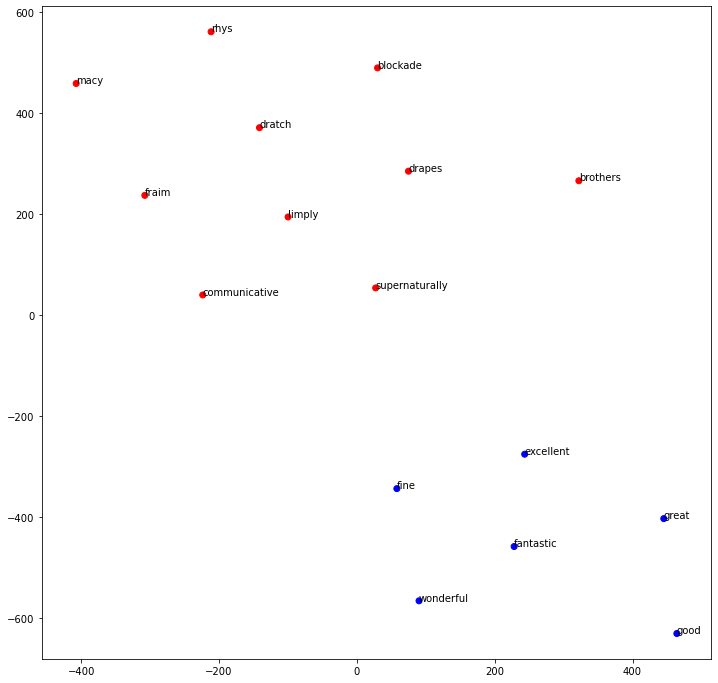

In [19]:
word = 'great'
# Obtener las 5 palabras más similares
most_similar = model.wv.most_similar(word, topn=5)

sample_words = [word] + [similar_word for similar_word, _ in most_similar]
# Obtener otras 10 palabras al azar para comparar
np.random.seed(37)
random_words = np.random.choice(model.wv.index_to_key, 10)

# Crear una lista con todas las palabras a graficar
total_words = sample_words + list(random_words)

# Reducir las dimensiones de las palabras
vectors = reduce_dimensions(model, total_words)

# Graficar las palabras con las palabras relacionadas en azul y las aleatorias en rojo
plot_with_matplotlib(vectors, total_words, colors=['blue'] * len(sample_words) + ['red'] * len(random_words))

Como se puede observar en el gráfico, las palabras más similares a "great" (color azul) se grafican más cercanas en comparación a las palabras aleatorias (color rojo).

## 4.2. Analogías

Las incrustaciones también nos permiten encontrar analogías entre palabras, y son una forma de evaluar la calidad de la información preservada por el modelo Word2Vec.

worse es de bad como 'better'(resultado de (worse - bad) + good) es de good


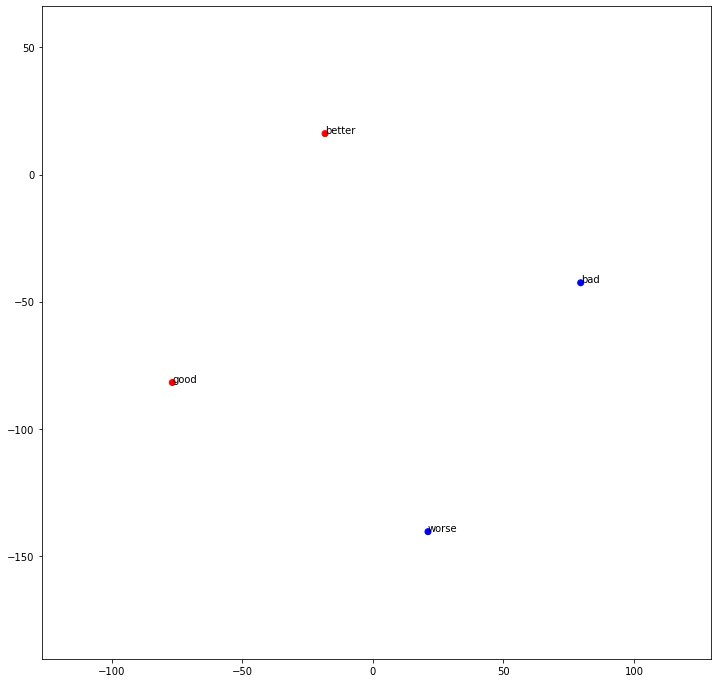

In [20]:
# Realizar la operación de analogía
pos = ["good", "worse"]
neg = ["bad"]
analogy = model.wv.most_similar(positive=pos, negative=neg, topn=1)
print(f"{pos[1]} es de {neg[0]} como '{analogy[0][0]}'(resultado de ({pos[1]} - {neg[0]}) + {pos[0]}) es de {pos[0]}")

# Crear grupos de palabras para graficar
first_group = [neg[0], pos[1]]
second_group = [pos[0], analogy[0][0]]

sample_words = first_group + second_group
vectors = reduce_dimensions(model, sample_words)

plot_with_matplotlib(vectors, sample_words, colors=['blue'] * len(first_group) + ['red'] * len(second_group))

brother es de boy como 'sister'(resultado de (brother - boy) + girl) es de girl


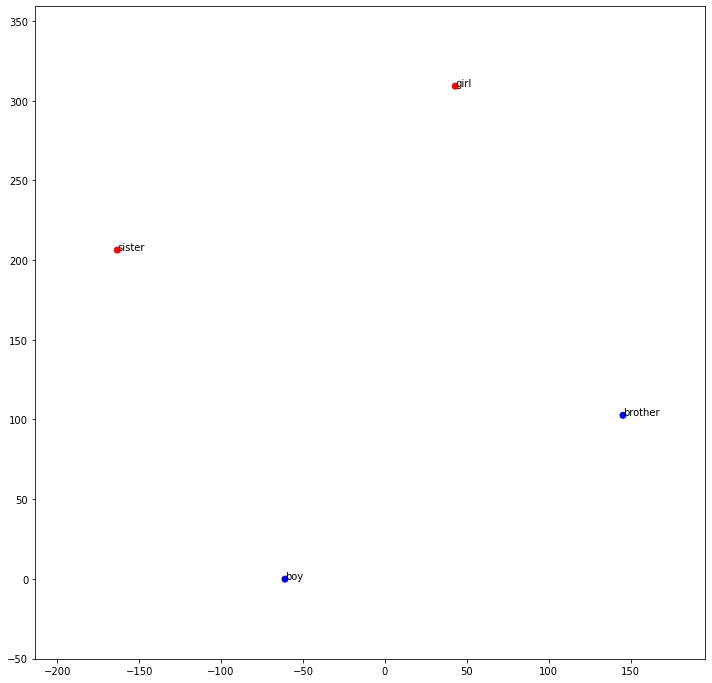

In [21]:
# Realizar la operación de analogía
pos = ["girl", "brother"]
neg = ["boy"]
analogy = model.wv.most_similar(positive=pos, negative=neg, topn=1)
print(f"{pos[1]} es de {neg[0]} como '{analogy[0][0]}'(resultado de ({pos[1]} - {neg[0]}) + {pos[0]}) es de {pos[0]}")

# Crear grupos de palabras para graficar
first_group = [neg[0], pos[1]]
second_group = [pos[0], analogy[0][0]]

sample_words = first_group + second_group
vectors = reduce_dimensions(model, sample_words)

plot_with_matplotlib(vectors, sample_words, colors=['blue'] * len(first_group) + ['red'] * len(second_group))

# 5. Conclusiones

Los modelos de tipo **Word2Vec** pueden ser valiosos para crear representaciones densas del texto que adicionalmente conservan información sintáctica y semántica del lenguaje. Tienen como ventaja que pueden ser más eficientes en memoria, y que la información que conservan pueden ser de mayor utilidad que las representaciones de bolsa de palabras para distintas tareas de PLN como la clasificación de texto.

Sin embargo, se debe tener en cuenta que estas representaciones son estáticas, por lo que una palabra siempre se representa de la misma manera a pesar de que su significado varíe de acuerdo al contexto.